In [1]:
import boto3

s3 = boto3.client("s3")

response = s3.list_buckets()

for bucket in response["Buckets"]:
    print(bucket["Name"], bucket["CreationDate"])


londonss 2025-12-27 23:01:31+00:00


In [20]:
import boto3

s3 = boto3.client("s3")
response = s3.list_objects_v2(Bucket="londonss")

if "Contents" in response:
    for obj in response["Contents"]:
        print(obj["Key"], obj["Size"], obj["LastModified"])
else:
    print("Bucket jest pusty")

athena-results/1b05a28a-e42d-49f1-a57f-28250cc559e1.txt 0 2025-12-28 21:17:01+00:00
athena-results/21abbd59-f2ca-4a91-a92b-4596a60d79b2.csv 118 2025-12-28 21:19:09+00:00
athena-results/21abbd59-f2ca-4a91-a92b-4596a60d79b2.csv.metadata 241 2025-12-28 21:19:09+00:00
athena-results/4470096f-293d-4732-8302-90f68df3bd1b.csv 91 2025-12-28 21:18:23+00:00
athena-results/4470096f-293d-4732-8302-90f68df3bd1b.csv.metadata 251 2025-12-28 21:18:23+00:00
athena-results/5ca9fb49-7f94-453b-9154-5166e140f04c.csv 391 2025-12-28 21:19:13+00:00
athena-results/5ca9fb49-7f94-453b-9154-5166e140f04c.csv.metadata 230 2025-12-28 21:19:13+00:00
athena-results/603f42f4-3d9b-4ef7-84e4-6959d41aad6c.csv 103 2025-12-28 21:18:18+00:00
athena-results/603f42f4-3d9b-4ef7-84e4-6959d41aad6c.csv.metadata 175 2025-12-28 21:18:18+00:00
athena-results/6fd028a5-6c23-4721-84f4-e17443f641ab.csv 568 2025-12-28 21:17:29+00:00
athena-results/6fd028a5-6c23-4721-84f4-e17443f641ab.csv.metadata 216 2025-12-28 21:17:30+00:00
athena-resul

In [3]:
import boto3
import pandas as pd
import io

# Inicjalizacja S3 clienta
s3 = boto3.client("s3")

bucket_name = "londonss"
file_key = "raw/LCL_2013.csv"

# Wczytanie pliku z S3
print("Ładowanie pliku z S3...")
try:
    response = s3.get_object(Bucket=bucket_name, Key=file_key)
    df = pd.read_csv(io.BytesIO(response["Body"].read()))
    print(f"✓ Plik wczytany! Rozmiar: {df.shape[0]} wierszy, {df.shape[1]} kolumn\n")
except Exception as e:
    print(f"Błąd: {e}")
    exit()

# === PODSTAWOWA EDA ===
print("="*60)
print("EXPLORATORY DATA ANALYSIS - LCL_2013")
print("="*60)

# 1. Info o dataframe
print("\n1. INFORMACJE OGÓLNE:")
print(f"Wymiary: {df.shape}")
print(f"\nTypy danych:\n{df.dtypes}")

# 2. Pierwsze wiersze
print("\n2. PIERWSZE 5 WIERSZY:")
print(df.head())

# 3. Statystyka opisowa
print("\n3. STATYSTYKA OPISOWA:")
print(df.describe())

# 4. Brakujące wartości
print("\n4. BRAKUJĄCE WARTOŚCI:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({"Kolumna": missing.index, "Brakujące": missing.values, "Procent": missing_pct.values})
print(missing_df[missing_df["Brakujące"] > 0])

# 5. Duplikaty
print(f"\n5. DUPLIKATY: {df.duplicated().sum()}")

# 6. Nazwy kolumn
print(f"\n6. NAZWY KOLUMN:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i}. {col}")

# 7. Rozkład wartości w kolumnach kategorycznych (jeśli istnieją)
print("\n7. WARTOŚCI UNIKALNE:")
for col in df.select_dtypes(include=['object']).columns:
    print(f"   {col}: {df[col].nunique()} unikalnych wartości")
    if df[col].nunique() <= 10:
        print(f"      {df[col].value_counts().to_dict()}")

Ładowanie pliku z S3...
✓ Plik wczytany! Rozmiar: 17520 wierszy, 4444 kolumn

EXPLORATORY DATA ANALYSIS - LCL_2013

1. INFORMACJE OGÓLNE:
Wymiary: (17520, 4444)

Typy danych:
DateTime      object
MAC000002    float64
MAC000003    float64
MAC000004    float64
MAC000006    float64
              ...   
MAC005561    float64
MAC005562    float64
MAC005563    float64
MAC005566    float64
MAC005567    float64
Length: 4444, dtype: object

2. PIERWSZE 5 WIERSZY:
                      DateTime  MAC000002  MAC000003  MAC000004  MAC000006  \
0  2013-01-01 00:30:00.0000000      0.241      1.922      0.000        0.0   
1  2013-01-01 01:00:00.0000000      0.191      1.808      0.000        0.0   
2  2013-01-01 01:30:00.0000000      0.235      0.795      0.158        0.0   
3  2013-01-01 02:00:00.0000000      0.182      1.235      0.000        0.0   
4  2013-01-01 02:30:00.0000000      0.229      0.924      0.000        0.0   

   MAC000007  MAC000008  MAC000009  MAC000010  MAC000011  ...  MAC005555 

In [22]:
import boto3
import pandas as pd
import io
import time

athena = boto3.client('athena')
s3 = boto3.client('s3')

# SQL query
response = athena.start_query_execution(
    QueryString='SELECT * FROM lcl_2013 LIMIT 5',
    QueryExecutionContext={'Database': 'energy_db'},
    ResultConfiguration={'OutputLocation': 's3://londonss/athena-results/'}
)

query_id = response['QueryExecutionId']
print(f"Query ID: {query_id}")

# Czekaj aż query się skończy
print("Czekam na wynik...")
for i in range(30):
    resp = athena.get_query_execution(QueryExecutionId=query_id)
    status = resp['QueryExecution']['Status']['State']
    
    if status == 'SUCCEEDED':
        print("✓ Query wykonany!")
        break
    elif status == 'FAILED':
        print(f"✗ Błąd: {resp['QueryExecution']['Status']['StateChangeReason']}")
        exit()
    else:
        print(f"Status: {status}...")
        time.sleep(1)

# Pobierz wyniki z S3
result_key = f"athena-results/{query_id}.csv"
resp = s3.get_object(Bucket='londonss', Key=result_key)
df = pd.read_csv(io.BytesIO(resp['Body'].read()))

# Wyświetl
print("\n5 pierwszych wierszy:")
print(df)
df.shape

Query ID: 558e654d-9334-4dcf-9764-866e297c858f
Czekam na wynik...
Status: QUEUED...
✓ Query wykonany!

5 pierwszych wierszy:
                      datetime  mac000002  mac000003  mac000004
0  2013-08-15 07:30:00.0000000      0.085      0.199      0.000
1  2013-08-15 08:00:00.0000000      0.154      0.176      0.000
2  2013-08-15 08:30:00.0000000      0.107      0.033      0.174
3  2013-08-15 09:00:00.0000000      0.151      0.116      0.000
4  2013-08-15 09:30:00.0000000      0.465      0.126      0.000


(5, 4)

In [25]:
import boto3
import pandas as pd
import io
import time

athena = boto3.client('athena')
s3 = boto3.client('s3')

# SQL query - MIN i MAXDateTime
response = athena.start_query_execution(
    QueryString='''
    SELECT 
    MIN(DateTime) as min_date,
    MAX(DateTime) as max_date
    FROM lcl_2013
    ''',
    QueryExecutionContext={'Database': 'energy_db'},
    ResultConfiguration={'OutputLocation': 's3://londonss/athena-results/'}
)

query_id = response['QueryExecutionId']
print(f"Query ID: {query_id}")

# Czekaj
print("Czekam na wynik...")
for i in range(30):
    resp = athena.get_query_execution(QueryExecutionId=query_id)
    status = resp['QueryExecution']['Status']['State']
    
    if status == 'SUCCEEDED':
        print("✓ Query wykonany!")
        break
    elif status == 'FAILED':
        print(f"✗ Błąd: {resp['QueryExecution']['Status']['StateChangeReason']}")
        exit()
    time.sleep(1)

# Pobierz wyniki
result_key = f"athena-results/{query_id}.csv"
resp = s3.get_object(Bucket='londonss', Key=result_key)
df = pd.read_csv(io.BytesIO(resp['Body'].read()))

print("\nZakres czasowy:")
print(df)


Query ID: db06a3f0-667c-43fe-93ed-55e74fb3c3d4
Czekam na wynik...
✓ Query wykonany!

Zakres czasowy:
                      min_date                     max_date
0  2013-01-01 00:30:00.0000000  2014-01-01 00:00:00.0000000


Query ID: c8e6fcc0-be06-42d5-8676-c444f8f22576
Czekam na wynik...
✓ Query wykonany!

Dane z 2013-01-15:
                       DateTime  MAC000002  MAC000003  MAC000004
0   2013-01-15 00:00:00.0000000      0.232      1.950      0.000
1   2013-01-15 00:30:00.0000000      0.248      1.876      0.000
2   2013-01-15 01:00:00.0000000      0.222      1.908      0.000
3   2013-01-15 01:30:00.0000000      0.259      2.065      0.000
4   2013-01-15 02:00:00.0000000      0.128      2.043      0.000
5   2013-01-15 02:30:00.0000000      0.127      2.116      0.136
6   2013-01-15 03:00:00.0000000      0.085      2.218      0.036
7   2013-01-15 03:30:00.0000000      0.113      2.233      0.000
8   2013-01-15 04:00:00.0000000      0.097      2.355      0.000
9   2013-01-15 04:30:00.0000000      0.098      2.292      0.000
10  2013-01-15 05:00:00.0000000      0.108      2.246      0.171
11  2013-01-15 05:30:00.0000000      0.086      2.304      0.000
12  2013-01-15 06:00:00.0000000      0.119      1.8

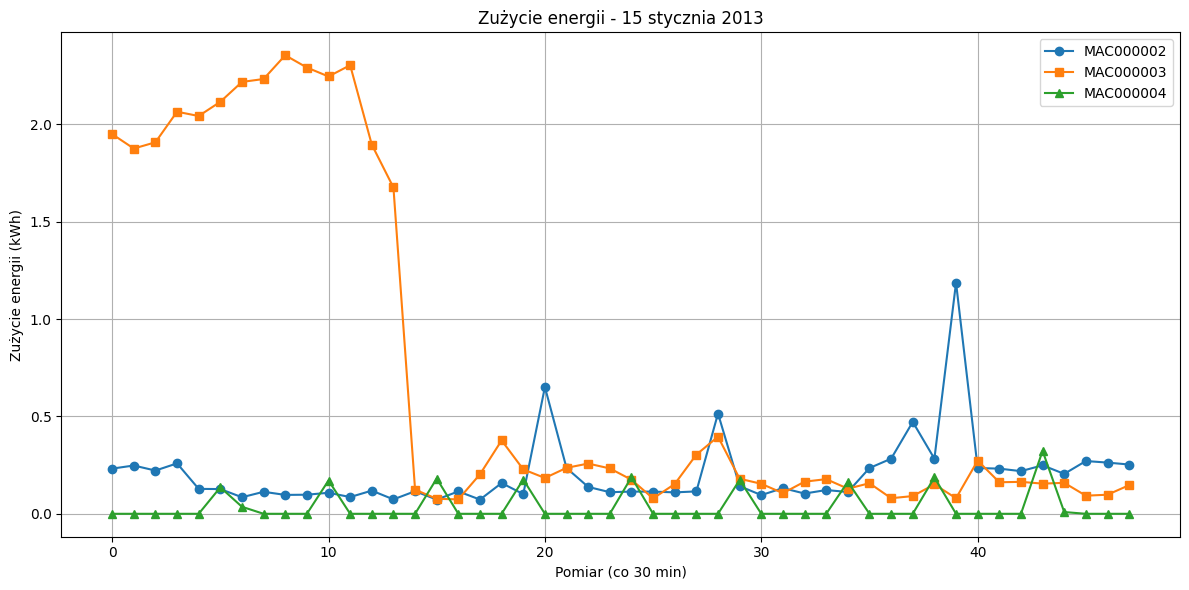


✓ Wykres zapisany: energy_day.png


In [26]:
import boto3
import pandas as pd
import io
import time
import matplotlib.pyplot as plt

athena = boto3.client('athena')
s3 = boto3.client('s3')

# SQL query - dane z jednego dnia
response = athena.start_query_execution(
    QueryString='''
    SELECT DateTime, MAC000002, MAC000003, MAC000004
    FROM lcl_2013
    WHERE DateTime LIKE '2013-01-15%'
    ORDER BY DateTime
    ''',
    QueryExecutionContext={'Database': 'energy_db'},
    ResultConfiguration={'OutputLocation': 's3://londonss/athena-results/'}
)

query_id = response['QueryExecutionId']
print(f"Query ID: {query_id}")

# Czekaj
print("Czekam na wynik...")
for i in range(30):
    resp = athena.get_query_execution(QueryExecutionId=query_id)
    status = resp['QueryExecution']['Status']['State']
    
    if status == 'SUCCEEDED':
        print("✓ Query wykonany!")
        break
    elif status == 'FAILED':
        print(f"✗ Błąd: {resp['QueryExecution']['Status']['StateChangeReason']}")
        exit()
    time.sleep(1)

# Pobierz wyniki
result_key = f"athena-results/{query_id}.csv"
resp = s3.get_object(Bucket='londonss', Key=result_key)
df = pd.read_csv(io.BytesIO(resp['Body'].read()))

print(f"\nDane z 2013-01-15:")
print(df)

# Rysuj wykres
plt.figure(figsize=(12, 6))

plt.plot(df.index, df['MAC000002'], label='MAC000002', marker='o')
plt.plot(df.index, df['MAC000003'], label='MAC000003', marker='s')
plt.plot(df.index, df['MAC000004'], label='MAC000004', marker='^')

plt.xlabel('Pomiar (co 30 min)')
plt.ylabel('Zużycie energii (kWh)')
plt.title('Zużycie energii - 15 stycznia 2013')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('energy_day.png')
plt.show()

print("\n✓ Wykres zapisany: energy_day.png")


In [27]:
import boto3
import pandas as pd
import io
import time

athena = boto3.client('athena')
s3 = boto3.client('s3')

# SQL query - suma zużycia dla każdego licznika
response = athena.start_query_execution(
    QueryString='''
    SELECT 
        'MAC000002' as meter,
        SUM(MAC000002) as total_consumption
    FROM lcl_2013
    WHERE MAC000002 IS NOT NULL
    UNION ALL
    SELECT 
        'MAC000003' as meter,
        SUM(MAC000003) as total_consumption
    FROM lcl_2013
    WHERE MAC000003 IS NOT NULL
    UNION ALL
    SELECT 
        'MAC000004' as meter,
        SUM(MAC000004) as total_consumption
    FROM lcl_2013
    WHERE MAC000004 IS NOT NULL
    ORDER BY total_consumption DESC
    ''',
    QueryExecutionContext={'Database': 'energy_db'},
    ResultConfiguration={'OutputLocation': 's3://londonss/athena-results/'}
)

query_id = response['QueryExecutionId']
print(f"Query ID: {query_id}\n")

# Czekaj
print("Czekam na wynik...")
for i in range(30):
    resp = athena.get_query_execution(QueryExecutionId=query_id)
    status = resp['QueryExecution']['Status']['State']
    
    if status == 'SUCCEEDED':
        print("✓ Query wykonany!\n")
        break
    elif status == 'FAILED':
        print(f"✗ Błąd: {resp['QueryExecution']['Status']['StateChangeReason']}")
        exit()
    time.sleep(1)

# Pobierz wyniki
result_key = f"athena-results/{query_id}.csv"
resp = s3.get_object(Bucket='londonss', Key=result_key)
df = pd.read_csv(io.BytesIO(resp['Body'].read()))

print("Łączne zużycie energii dla każdego licznika:")
print(df)

Query ID: 3fd0baba-bb20-4844-8899-a56cbc995adc

Czekam na wynik...
✓ Query wykonany!

Łączne zużycie energii dla każdego licznika:
       meter  total_consumption
0  MAC000003        7008.341004
1  MAC000002        4214.925000
2  MAC000004         618.246000


Query ID: dc0b1890-a180-4079-88de-ca10f85a1ecb

Czekam na wynik...
✓ Query wykonany!

Dane z tygodnia (1-7 stycznia 2013):
                      DateTime  MAC000003
0  2013-01-01 00:30:00.0000000      1.922
1  2013-01-01 01:00:00.0000000      1.808
2  2013-01-01 01:30:00.0000000      0.795
3  2013-01-01 02:00:00.0000000      1.235
4  2013-01-01 02:30:00.0000000      0.924
5  2013-01-01 03:00:00.0000000      1.149
6  2013-01-01 03:30:00.0000000      0.891
7  2013-01-01 04:00:00.0000000      1.173
8  2013-01-01 04:30:00.0000000      0.322
9  2013-01-01 05:00:00.0000000      0.559
... łącznie 335 wierszy



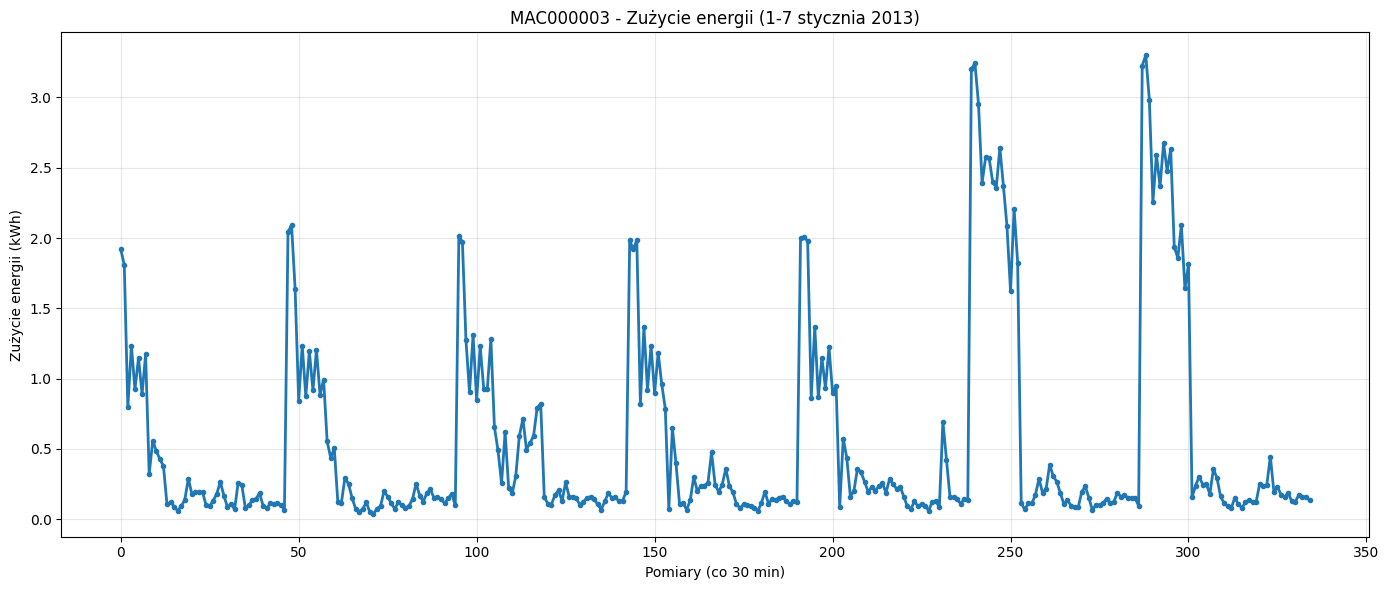

✓ Wykres zapisany: energy_week.png


In [28]:
import boto3
import pandas as pd
import io
import time
import matplotlib.pyplot as plt

athena = boto3.client('athena')
s3 = boto3.client('s3')

# SQL query - jeden tydzień dla MAC000003
response = athena.start_query_execution(
    QueryString='''
    SELECT DateTime, MAC000003
    FROM lcl_2013
    WHERE DateTime >= '2013-01-01' AND DateTime < '2013-01-08'
    ORDER BY DateTime
    ''',
    QueryExecutionContext={'Database': 'energy_db'},
    ResultConfiguration={'OutputLocation': 's3://londonss/athena-results/'}
)

query_id = response['QueryExecutionId']
print(f"Query ID: {query_id}\n")

# Czekaj
print("Czekam na wynik...")
for i in range(30):
    resp = athena.get_query_execution(QueryExecutionId=query_id)
    status = resp['QueryExecution']['Status']['State']
    
    if status == 'SUCCEEDED':
        print("✓ Query wykonany!\n")
        break
    elif status == 'FAILED':
        print(f"✗ Błąd: {resp['QueryExecution']['Status']['StateChangeReason']}")
        exit()
    time.sleep(1)

# Pobierz wyniki
result_key = f"athena-results/{query_id}.csv"
resp = s3.get_object(Bucket='londonss', Key=result_key)
df = pd.read_csv(io.BytesIO(resp['Body'].read()))

print(f"Dane z tygodnia (1-7 stycznia 2013):")
print(df.head(10))
print(f"... łącznie {len(df)} wierszy\n")

# Rysuj wykres
plt.figure(figsize=(14, 6))
plt.plot(range(len(df)), df['MAC000003'], linewidth=2, marker='o', markersize=3)

plt.xlabel('Pomiary (co 30 min)')
plt.ylabel('Zużycie energii (kWh)')
plt.title('MAC000003 - Zużycie energii (1-7 stycznia 2013)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('energy_week.png', dpi=100)
plt.show()

print("✓ Wykres zapisany: energy_week.png")


Query ID: 0607ef56-e69e-40ac-b692-0da1caae1fb4

Czekam na wynik...
✓ Query wykonany!

Dane agregowane na dzień:
         date  daily_avg  daily_sum
0  2013-01-01      0.357     16.768
1  2013-01-02      0.416     19.980
2  2013-01-03      0.490     23.522
3  2013-01-04      0.436     20.949
4  2013-01-05      0.460     22.061
5  2013-01-06      0.829     39.806
6  2013-01-07      0.837     40.185
7  2013-01-08      0.839     40.282
8  2013-01-09      0.409     19.656
9  2013-01-10      0.839     40.258
... łącznie 366 dni



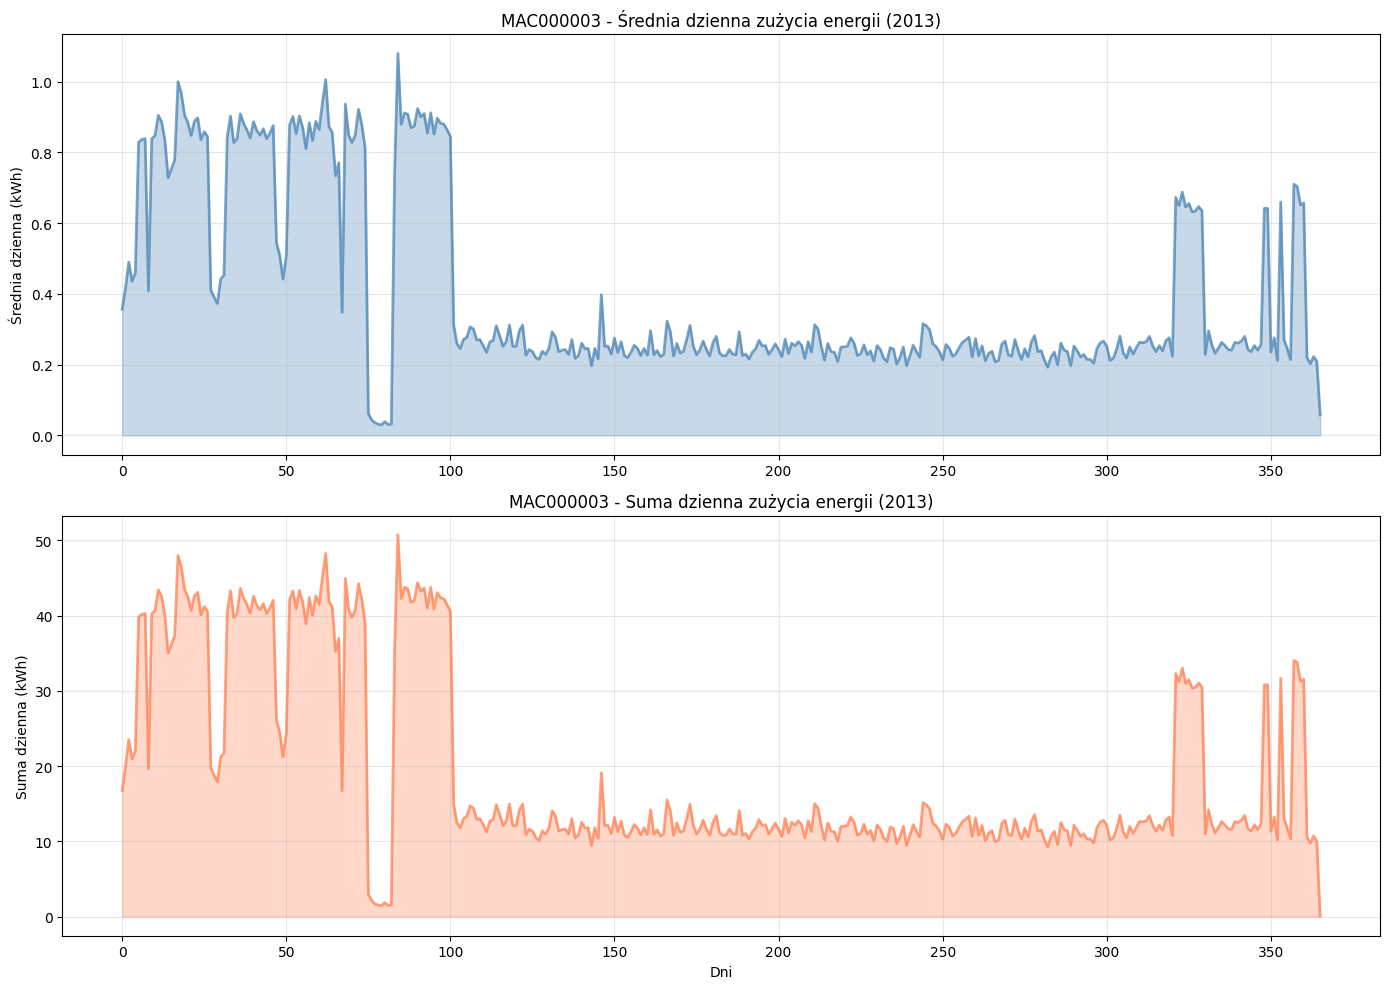

✓ Wykres zapisany: energy_year.png


In [29]:
import boto3
import pandas as pd
import io
import time
import matplotlib.pyplot as plt

athena = boto3.client('athena')
s3 = boto3.client('s3')

# SQL query - całe dane zagregowane na dzień
response = athena.start_query_execution(
    QueryString='''
    SELECT 
        SUBSTR(DateTime, 1, 10) as date,
        ROUND(AVG(MAC000003), 3) as daily_avg,
        ROUND(SUM(MAC000003), 3) as daily_sum
    FROM lcl_2013
    WHERE MAC000003 IS NOT NULL
    GROUP BY SUBSTR(DateTime, 1, 10)
    ORDER BY date
    ''',
    QueryExecutionContext={'Database': 'energy_db'},
    ResultConfiguration={'OutputLocation': 's3://londonss/athena-results/'}
)

query_id = response['QueryExecutionId']
print(f"Query ID: {query_id}\n")

# Czekaj
print("Czekam na wynik...")
for i in range(30):
    resp = athena.get_query_execution(QueryExecutionId=query_id)
    status = resp['QueryExecution']['Status']['State']
    
    if status == 'SUCCEEDED':
        print("✓ Query wykonany!\n")
        break
    elif status == 'FAILED':
        print(f"✗ Błąd: {resp['QueryExecution']['Status']['StateChangeReason']}")
        exit()
    time.sleep(1)

# Pobierz wyniki
result_key = f"athena-results/{query_id}.csv"
resp = s3.get_object(Bucket='londonss', Key=result_key)
df = pd.read_csv(io.BytesIO(resp['Body'].read()))

print(f"Dane agregowane na dzień:")
print(df.head(10))
print(f"... łącznie {len(df)} dni\n")

# Rysuj wykres
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Wykres 1: Średnia dzienna
axes[0].plot(range(len(df)), df['daily_avg'], linewidth=2, color='steelblue', alpha=0.7)
axes[0].fill_between(range(len(df)), df['daily_avg'], alpha=0.3, color='steelblue')
axes[0].set_ylabel('Średnia dzienna (kWh)')
axes[0].set_title('MAC000003 - Średnia dzienna zużycia energii (2013)')
axes[0].grid(True, alpha=0.3)

# Wykres 2: Suma dzienna
axes[1].plot(range(len(df)), df['daily_sum'], linewidth=2, color='coral', alpha=0.7)
axes[1].fill_between(range(len(df)), df['daily_sum'], alpha=0.3, color='coral')
axes[1].set_xlabel('Dni')
axes[1].set_ylabel('Suma dzienna (kWh)')
axes[1].set_title('MAC000003 - Suma dzienna zużycia energii (2013)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('energy_year.png', dpi=100)
plt.show()

print("✓ Wykres zapisany: energy_year.png")

In [30]:
import boto3
import pandas as pd
import io
import time
import matplotlib.pyplot as plt
import numpy as np

athena = boto3.client('athena')
s3 = boto3.client('s3')

# SQL query - całe dane dla MAC000003
response = athena.start_query_execution(
    QueryString='''
    SELECT 
        DateTime,
        MAC000003
    FROM lcl_2013
    WHERE MAC000003 IS NOT NULL
    ORDER BY DateTime
    ''',
    QueryExecutionContext={'Database': 'energy_db'},
    ResultConfiguration={'OutputLocation': 's3://londonss/athena-results/'}
)

query_id = response['QueryExecutionId']
print(f"Query ID: {query_id}\n")

# Czekaj
print("Czekam na wynik...")
for i in range(60):
    resp = athena.get_query_execution(QueryExecutionId=query_id)
    status = resp['QueryExecution']['Status']['State']
    
    if status == 'SUCCEEDED':
        print("✓ Query wykonany!\n")
        break
    elif status == 'FAILED':
        print(f"✗ Błąd: {resp['QueryExecution']['Status']['StateChangeReason']}")
        exit()
    time.sleep(1)

# Pobierz wyniki
result_key = f"athena-results/{query_id}.csv"
resp = s3.get_object(Bucket='londonss', Key=result_key)
df = pd.read_csv(io.BytesIO(resp['Body'].read()))

# Przygotuj dane
df['DateTime'] = pd.to_datetime(df['DateTime'])
df = df.sort_values('DateTime')
df.set_index('DateTime', inplace=True)

print("Dane przygotowane:")
print(df.head(10))
print(f"\nRozmiar: {len(df)} obserwacji")
print(f"Zakres: {df.index.min()} do {df.index.max()}")

Query ID: 2a56b9c2-fdc2-4ab6-923a-3a21a86a83d6

Czekam na wynik...
✓ Query wykonany!

Dane przygotowane:
                     MAC000003
DateTime                      
2013-01-01 00:30:00      1.922
2013-01-01 01:00:00      1.808
2013-01-01 01:30:00      0.795
2013-01-01 02:00:00      1.235
2013-01-01 02:30:00      0.924
2013-01-01 03:00:00      1.149
2013-01-01 03:30:00      0.891
2013-01-01 04:00:00      1.173
2013-01-01 04:30:00      0.322
2013-01-01 05:00:00      0.559

Rozmiar: 17518 obserwacji
Zakres: 2013-01-01 00:30:00 do 2014-01-01 00:00:00


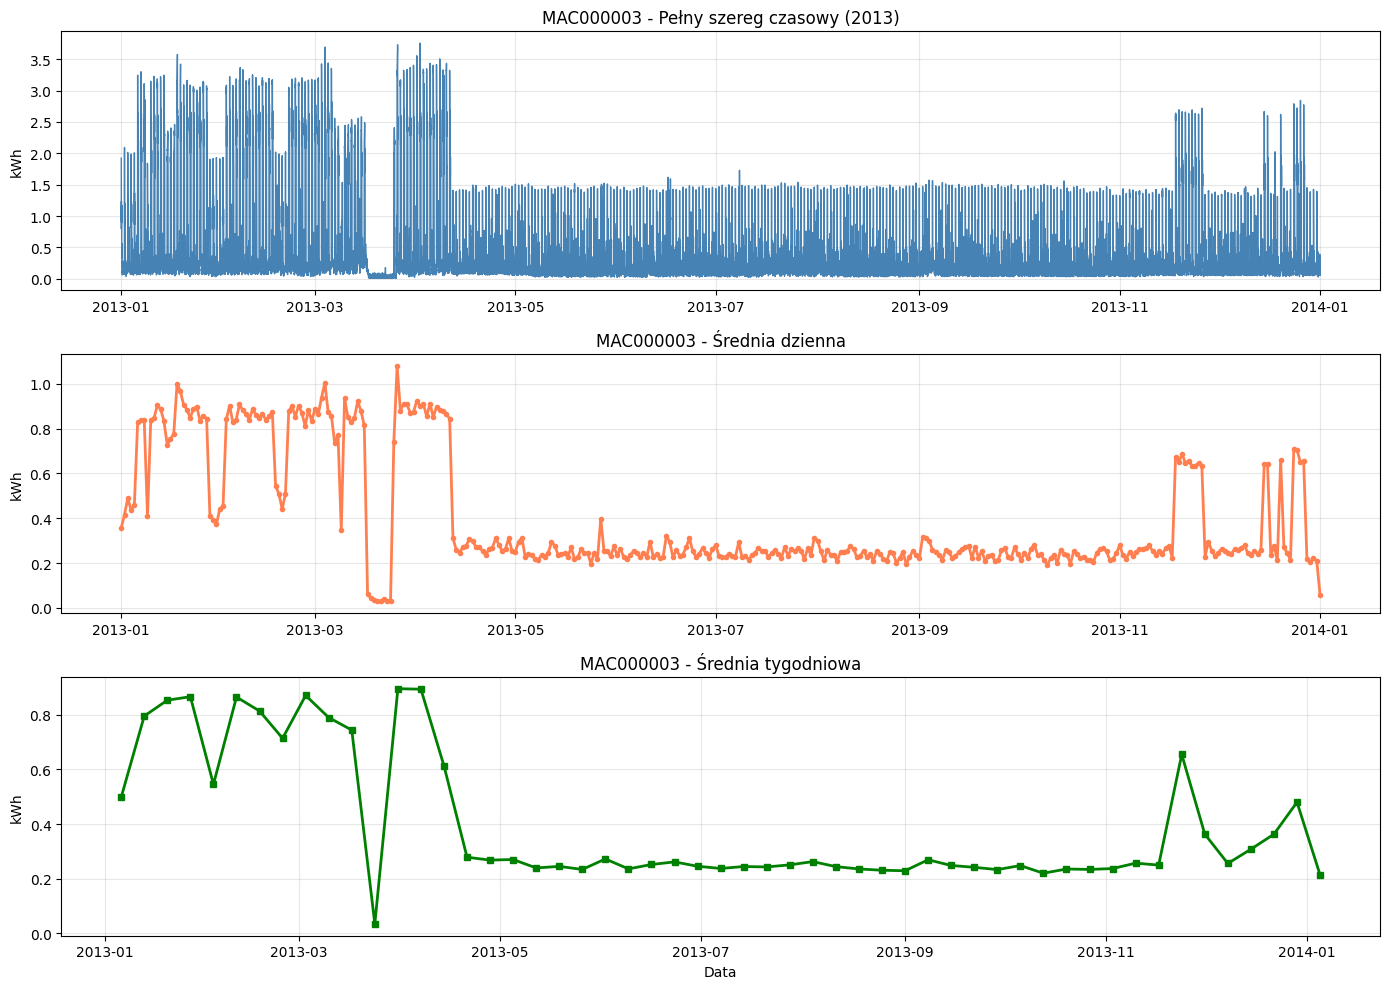

✓ Wykres zapisany: timeseries_visualization.png


In [31]:
# Wizualizacja
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# 1. Cały szereg czasowy
axes[0].plot(df.index, df['MAC000003'], linewidth=1, color='steelblue')
axes[0].set_title('MAC000003 - Pełny szereg czasowy (2013)')
axes[0].set_ylabel('kWh')
axes[0].grid(True, alpha=0.3)

# 2. Agregacja na dzień (łatwiej widać trend)
daily = df.resample('D').mean()
axes[1].plot(daily.index, daily['MAC000003'], linewidth=2, color='coral', marker='o', markersize=3)
axes[1].set_title('MAC000003 - Średnia dzienna')
axes[1].set_ylabel('kWh')
axes[1].grid(True, alpha=0.3)

# 3. Agregacja na tydzień
weekly = df.resample('W').mean()
axes[2].plot(weekly.index, weekly['MAC000003'], linewidth=2, color='green', marker='s', markersize=5)
axes[2].set_title('MAC000003 - Średnia tygodniowa')
axes[2].set_xlabel('Data')
axes[2].set_ylabel('kWh')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('timeseries_visualization.png', dpi=100)
plt.show()

print("✓ Wykres zapisany: timeseries_visualization.png")

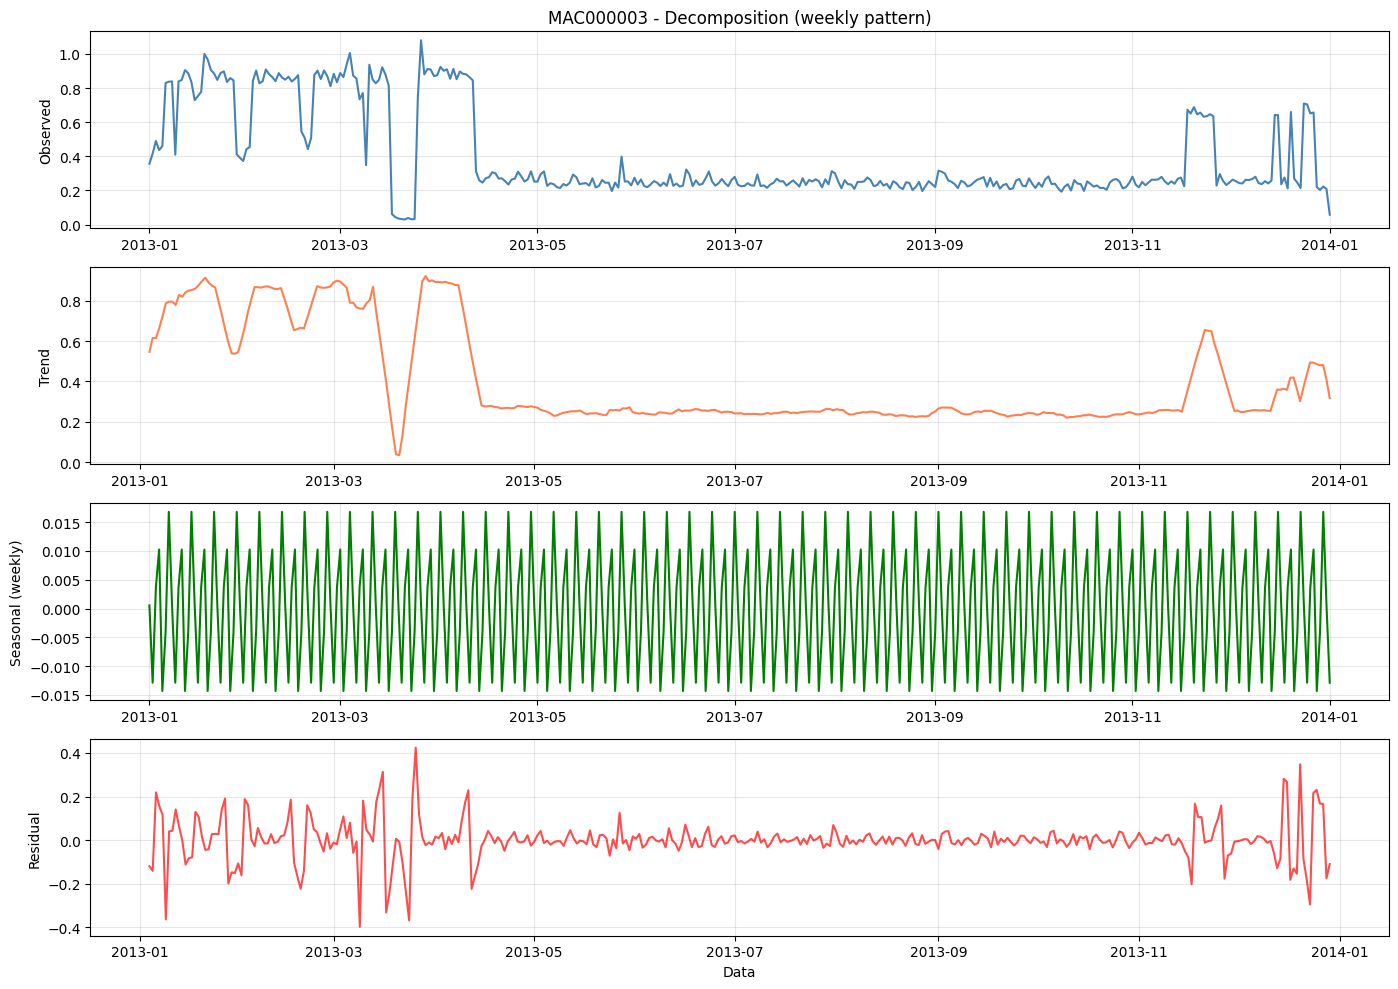

✓ Decomposition zapisany: decomposition.png


In [34]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Użyj danych dziennych
daily = df.resample('D').mean()

# Decomposition - period=7 (tydzień zamiast roku)
decomposition = seasonal_decompose(daily['MAC000003'], model='additive', period=7)

# Rysuj
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

# Original
axes[0].plot(decomposition.observed.index, decomposition.observed.values, color='steelblue')
axes[0].set_ylabel('Observed')
axes[0].set_title('MAC000003 - Decomposition (weekly pattern)')
axes[0].grid(True, alpha=0.3)

# Trend
axes[1].plot(decomposition.trend.index, decomposition.trend.values, color='coral')
axes[1].set_ylabel('Trend')
axes[1].grid(True, alpha=0.3)

# Seasonal
axes[2].plot(decomposition.seasonal.index, decomposition.seasonal.values, color='green')
axes[2].set_ylabel('Seasonal (weekly)')
axes[2].grid(True, alpha=0.3)

# Residual
axes[3].plot(decomposition.resid.index, decomposition.resid.values, color='red', alpha=0.7)
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Data')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('decomposition.png', dpi=100)
plt.show()

print("✓ Decomposition zapisany: decomposition.png")

In [35]:
from statsmodels.tsa.stattools import adfuller

# Test stacjonarności
result = adfuller(daily['MAC000003'].dropna())

print("ADF Test Results:")
print(f"ADF Statistic: {result[0]:.6f}")
print(f"P-value: {result[1]:.6f}")
print(f"Critical Values:")
for key, value in result[4].items():
    print(f"  {key}: {value:.3f}")

if result[1] <= 0.05:
    print("\n✓ Szereg jest STATIONARY (można robić forecast)")
else:
    print("\n✗ Szereg NIE jest stationary (trzeba go transformować)")

ADF Test Results:
ADF Statistic: -4.301939
P-value: 0.000441
Critical Values:
  1%: -3.448
  5%: -2.869
  10%: -2.571

✓ Szereg jest STATIONARY (można robić forecast)


Train: 292 dni
Test: 74 dni

Trenowanie ARIMA(1,1,1)...
                               SARIMAX Results                                
Dep. Variable:              MAC000003   No. Observations:                  292
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 233.785
Date:                Mon, 29 Dec 2025   AIC                           -461.570
Time:                        00:49:51   BIC                           -450.550
Sample:                    01-01-2013   HQIC                          -457.156
                         - 10-19-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8230      0.040     20.374      0.000       0.744       0.902
ma.L1         -0.9611      0.030    -31.912      0.000      -1.020      -0.

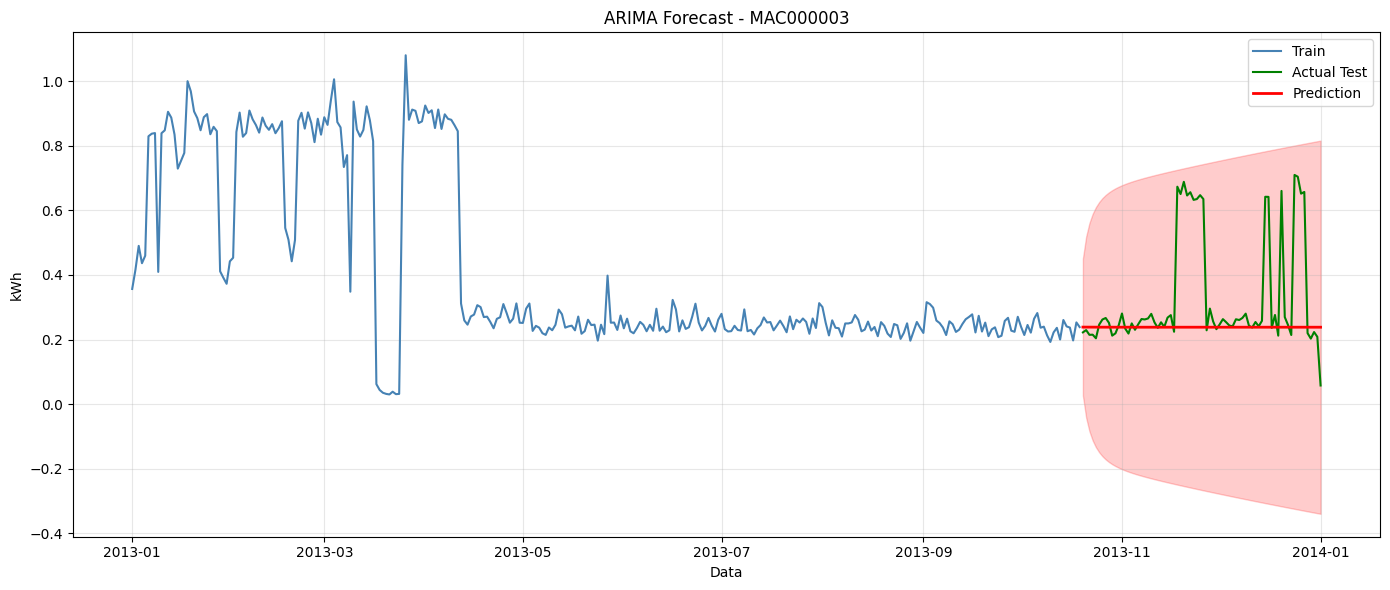


✓ Forecast zapisany: arima_forecast.png


In [37]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Podziel na train i test
train_size = int(len(daily) * 0.8)
train, test = daily[:train_size], daily[train_size:]

print(f"Train: {len(train)} dni")
print(f"Test: {len(test)} dni\n")

# Trenuj model ARIMA
print("Trenowanie ARIMA(1,1,1)...")
model = ARIMA(train['MAC000003'], order=(1, 1, 1))
fitted_model = model.fit()

print(fitted_model.summary())

# Predykcja na danych testowych
predictions = fitted_model.get_forecast(steps=len(test))
pred_df = predictions.conf_int()
pred_df['predicted'] = predictions.predicted_mean

# Metryki
mae = mean_absolute_error(test['MAC000003'], pred_df['predicted'])
rmse = np.sqrt(mean_squared_error(test['MAC000003'], pred_df['predicted']))

print(f"\n\nMetryki:")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

# Wizualizacja
plt.figure(figsize=(14, 6))
plt.plot(train.index, train['MAC000003'], label='Train', color='steelblue')
plt.plot(test.index, test['MAC000003'], label='Actual Test', color='green')
plt.plot(test.index, pred_df['predicted'], label='Prediction', color='red', linewidth=2)
plt.fill_between(test.index, pred_df.iloc[:, 0], pred_df.iloc[:, 1], alpha=0.2, color='red')

plt.xlabel('Data')
plt.ylabel('kWh')
plt.title('ARIMA Forecast - MAC000003')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('arima_forecast.png', dpi=100)
plt.show()

print("\n✓ Forecast zapisany: arima_forecast.png")

Importing plotly failed. Interactive plots will not work.
00:54:28 - cmdstanpy - INFO - Chain [1] start processing


Trenowanie Prophet...


00:54:28 - cmdstanpy - INFO - Chain [1] done processing



Prophet Metryki:
MAE: 0.1314
RMSE: 0.2140


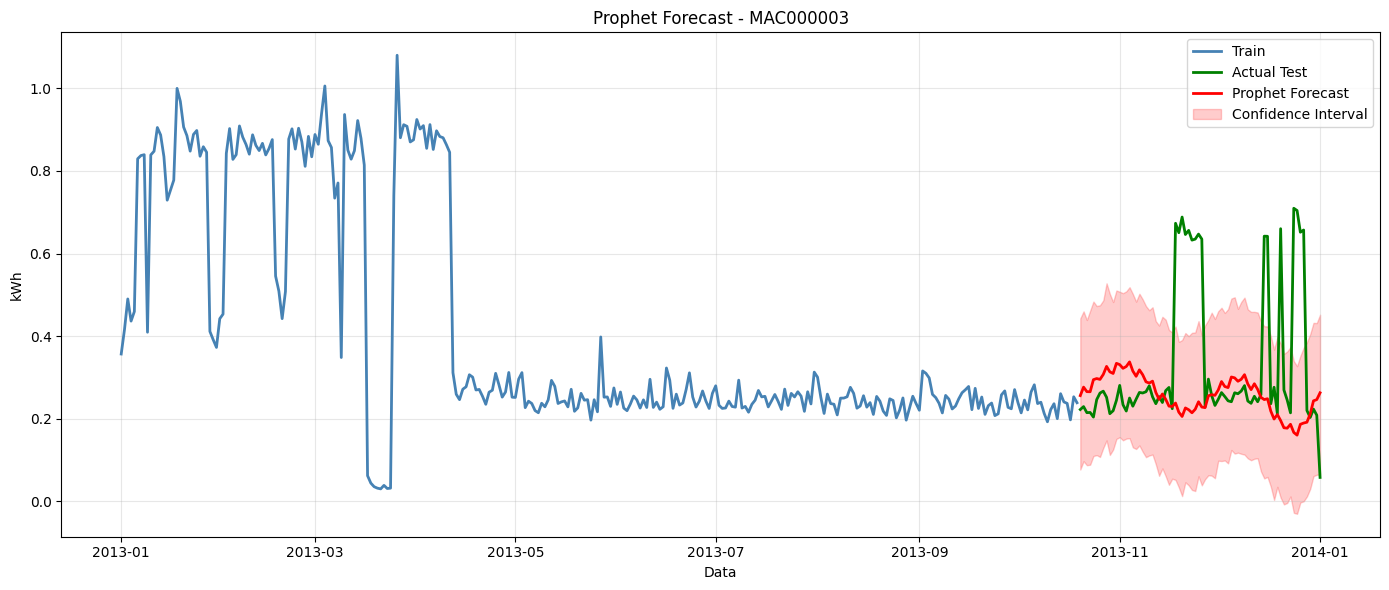


✓ Forecast zapisany: prophet_forecast.png


In [39]:
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

# Przygotuj dane w formacie Prophet (ds, y)
train_prophet = pd.DataFrame({
    'ds': train.index,
    'y': train['MAC000003'].values
})

test_prophet = pd.DataFrame({
    'ds': test.index,
    'y': test['MAC000003'].values
})

# Trenuj Prophet
print("Trenowanie Prophet...")
model_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model_prophet.fit(train_prophet)

# Predykcja
future = pd.DataFrame({'ds': test.index})
forecast = model_prophet.make_future_dataframe(periods=len(test))
forecast = model_prophet.predict(forecast)

# Weź tylko część dla testu
forecast_test = forecast[forecast['ds'].isin(test.index)].copy()

# Metryki
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_prophet = mean_absolute_error(test['MAC000003'], forecast_test['yhat'])
rmse_prophet = np.sqrt(mean_squared_error(test['MAC000003'], forecast_test['yhat']))

print(f"\nProphet Metryki:")
print(f"MAE: {mae_prophet:.4f}")
print(f"RMSE: {rmse_prophet:.4f}")

# Wizualizacja
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(train.index, train['MAC000003'], label='Train', color='steelblue', linewidth=2)
ax.plot(test.index, test['MAC000003'], label='Actual Test', color='green', linewidth=2)
ax.plot(forecast_test['ds'], forecast_test['yhat'], label='Prophet Forecast', color='red', linewidth=2)
ax.fill_between(forecast_test['ds'], forecast_test['yhat_lower'], forecast_test['yhat_upper'], 
                 alpha=0.2, color='red', label='Confidence Interval')

ax.set_xlabel('Data')
ax.set_ylabel('kWh')
ax.set_title('Prophet Forecast - MAC000003')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('prophet_forecast.png', dpi=100)
plt.show()

print("\n✓ Forecast zapisany: prophet_forecast.png")

In [16]:
import boto3
import time
import pandas as pd
import io

athena = boto3.client('athena')
s3 = boto3.client('s3')

def run_query(query_string, database='energy_db'):
    """Wykonaj query w Athenie i pobierz wyniki"""
    response = athena.start_query_execution(
        QueryString=query_string,
        QueryExecutionContext={'Database': database},
        ResultConfiguration={'OutputLocation': 's3://londonss/athena-results/'}
    )
    
    query_id = response['QueryExecutionId']
    
    # Czekaj na wynik
    for i in range(60):
        response = athena.get_query_execution(QueryExecutionId=query_id)
        status = response['QueryExecution']['Status']['State']
        
        if status == 'SUCCEEDED':
            break
        elif status == 'FAILED':
            print(f"✗ Błąd: {response['QueryExecution']['Status']['StateChangeReason']}")
            return None
        else:
            time.sleep(1)
    
    # Pobierz wyniki
    result_key = f"athena-results/{query_id}.csv"
    response = s3.get_object(Bucket='londonss', Key=result_key)
    df = pd.read_csv(io.BytesIO(response['Body'].read()))
    
    return df

print("="*70)
print("ENERGY DATA EDA - AWS Athena SQL")
print("="*70)

# 1. Liczba wierszy i info o DateTime
print("\n1. ZAKRES CZASOWY:")
result = run_query("""
    SELECT 
        MIN(DateTime) as min_date,
        MAX(DateTime) as max_date,
        COUNT(*) as total_rows
    FROM lcl_2013
""")
print(result)

# 2. Liczba kolumn (liczników)
print("\n2. LICZBA LICZNIKÓW:")
print("Liczba kolumn (liczników): 4443")  # DateTime + 4442 liczniki

# 3. Statystyka zużycia dla wybranych liczników
print("\n3. STATYSTYKA ZUŻYCIA (przykład - MAC000002):")
result = run_query("""
    SELECT 
        COUNT(*) as count,
        MIN(MAC000002) as min_val,
        MAX(MAC000002) as max_val,
        AVG(MAC000002) as avg_val,
        APPROX_PERCENTILE(MAC000002, 0.5) as median_val
    FROM lcl_2013
    WHERE MAC000002 IS NOT NULL
""")
print(result)

# 4. Brakujące wartości (NULL counts)
print("\n4. BRAKUJĄCE WARTOŚCI (NULL) - TOP 10:")
result = run_query("""
    SELECT 
        COUNT(*) - COUNT(MAC000002) as nulls_mac000002,
        COUNT(*) - COUNT(MAC000003) as nulls_mac000003,
        COUNT(*) - COUNT(MAC000004) as nulls_mac000004,
        COUNT(*) as total_rows
    FROM lcl_2013
""")
print(result)

# 5. Liczniki z wartościami zerowymi
print("\n5. LICZNIKI Z WARTOŚCIAMI ZEROWYMI:")
result = run_query("""
    SELECT 
        SUM(CASE WHEN MAC000002 = 0 THEN 1 ELSE 0 END) as zeros_mac000002,
        SUM(CASE WHEN MAC000003 = 0 THEN 1 ELSE 0 END) as zeros_mac000003,
        SUM(CASE WHEN MAC000004 = 0 THEN 1 ELSE 0 END) as zeros_mac000004,
        COUNT(*) as total_rows
    FROM lcl_2013
""")
print(result)

# 6. Zagregowane zużycie po dniu (daily pattern)
print("\n6. ŚREDNIE DZIENNE ZUŻYCIE (przykład):")
result = run_query("""
    SELECT 
        DATE(DateTime) as date,
        ROUND(AVG(MAC000002), 3) as avg_mac000002,
        ROUND(AVG(MAC000003), 3) as avg_mac000003,
        COUNT(*) as measurements
    FROM lcl_2013
    WHERE MAC000002 IS NOT NULL AND MAC000003 IS NOT NULL
    GROUP BY DATE(DateTime)
    ORDER BY date
    LIMIT 10
""")
print(result)

# 7. Wzorzec godzinowy (hourly pattern)
print("\n7. ZUŻYCIE PO GODZINACH DNIA:")
result = run_query("""
    SELECT 
        HOUR(DateTime) as hour,
        ROUND(AVG(MAC000002), 3) as avg_mac000002,
        ROUND(AVG(MAC000003), 3) as avg_mac000003,
        COUNT(*) as measurements
    FROM lcl_2013
    WHERE MAC000002 IS NOT NULL AND MAC000003 IS NOT NULL
    GROUP BY HOUR(DateTime)
    ORDER BY hour
""")
print(result)

print("\n" + "="*70)
print("✓ EDA zakończona!")
print("="*70)

ENERGY DATA EDA - AWS Athena SQL

1. ZAKRES CZASOWY:
                      min_date                     max_date  total_rows
0  2013-01-01 00:30:00.0000000  2014-01-01 00:00:00.0000000       17520

2. LICZBA LICZNIKÓW:
Liczba kolumn (liczników): 4443

3. STATYSTYKA ZUŻYCIA (przykład - MAC000002):
   count  min_val  max_val   avg_val  median_val
0  17520    0.065    2.994  0.240578    0.151194

4. BRAKUJĄCE WARTOŚCI (NULL) - TOP 10:
   nulls_mac000002  nulls_mac000003  nulls_mac000004  total_rows
0                0                2                1       17520

5. LICZNIKI Z WARTOŚCIAMI ZEROWYMI:
   zeros_mac000002  zeros_mac000003  zeros_mac000004  total_rows
0                0                0            13442       17520

6. ŚREDNIE DZIENNE ZUŻYCIE (przykład):
✗ Błąd: INVALID_CAST_ARGUMENT: Value cannot be cast to date: 2013-11-29 09:00:00.0000000
None

7. ZUŻYCIE PO GODZINACH DNIA:
✗ Błąd: FUNCTION_NOT_FOUND: line 2:9: Unexpected parameters (varchar) for function hour. Expected: hou

In [17]:
import boto3
import time
import pandas as pd
import io

athena = boto3.client('athena')
s3 = boto3.client('s3')

def run_query(query_string, database='energy_db'):
    """Wykonaj query w Athenie i pobierz wyniki"""
    response = athena.start_query_execution(
        QueryString=query_string,
        QueryExecutionContext={'Database': database},
        ResultConfiguration={'OutputLocation': 's3://londonss/athena-results/'}
    )
    
    query_id = response['QueryExecutionId']
    
    # Czekaj na wynik
    for i in range(60):
        response = athena.get_query_execution(QueryExecutionId=query_id)
        status = response['QueryExecution']['Status']['State']
        
        if status == 'SUCCEEDED':
            break
        elif status == 'FAILED':
            print(f"✗ Błąd: {response['QueryExecution']['Status']['StateChangeReason']}")
            return None
        else:
            time.sleep(1)
    
    # Pobierz wyniki
    result_key = f"athena-results/{query_id}.csv"
    response = s3.get_object(Bucket='londonss', Key=result_key)
    df = pd.read_csv(io.BytesIO(response['Body'].read()))
    
    return df

print("="*70)
print("ENERGY DATA EDA - AWS Athena SQL")
print("="*70)

# 1. Liczba wierszy i info o DateTime
print("\n1. ZAKRES CZASOWY:")
result = run_query("""
    SELECT 
        MIN(DateTime) as min_date,
        MAX(DateTime) as max_date,
        COUNT(*) as total_rows
    FROM lcl_2013
""")
print(result)

# 2. Liczba kolumn (liczników)
print("\n2. LICZBA LICZNIKÓW:")
print("Liczba kolumn (liczników): 4443")  # DateTime + 4442 liczniki

# 3. Statystyka zużycia dla wybranych liczników
print("\n3. STATYSTYKA ZUŻYCIA (przykład - MAC000002):")
result = run_query("""
    SELECT 
        COUNT(*) as count,
        MIN(MAC000002) as min_val,
        MAX(MAC000002) as max_val,
        AVG(MAC000002) as avg_val,
        APPROX_PERCENTILE(MAC000002, 0.5) as median_val
    FROM lcl_2013
    WHERE MAC000002 IS NOT NULL
""")
print(result)

# 4. Brakujące wartości (NULL counts)
print("\n4. BRAKUJĄCE WARTOŚCI (NULL) - TOP 10:")
result = run_query("""
    SELECT 
        COUNT(*) - COUNT(MAC000002) as nulls_mac000002,
        COUNT(*) - COUNT(MAC000003) as nulls_mac000003,
        COUNT(*) - COUNT(MAC000004) as nulls_mac000004,
        COUNT(*) as total_rows
    FROM lcl_2013
""")
print(result)

# 5. Liczniki z wartościami zerowymi
print("\n5. LICZNIKI Z WARTOŚCIAMI ZEROWYMI:")
result = run_query("""
    SELECT 
        SUM(CASE WHEN MAC000002 = 0 THEN 1 ELSE 0 END) as zeros_mac000002,
        SUM(CASE WHEN MAC000003 = 0 THEN 1 ELSE 0 END) as zeros_mac000003,
        SUM(CASE WHEN MAC000004 = 0 THEN 1 ELSE 0 END) as zeros_mac000004,
        COUNT(*) as total_rows
    FROM lcl_2013
""")
print(result)

# 6. Zagregowane zużycie po dniu (daily pattern)
print("\n6. ŚREDNIE DZIENNE ZUŻYCIE (przykład):")
result = run_query("""
    SELECT 
        SUBSTR(DateTime, 1, 10) as date,
        ROUND(AVG(MAC000002), 3) as avg_mac000002,
        ROUND(AVG(MAC000003), 3) as avg_mac000003,
        COUNT(*) as measurements
    FROM lcl_2013
    WHERE MAC000002 IS NOT NULL AND MAC000003 IS NOT NULL
    GROUP BY SUBSTR(DateTime, 1, 10)
    ORDER BY date
    LIMIT 10
""")
print(result)

# 7. Wzorzec godzinowy (hourly pattern)
print("\n7. ZUŻYCIE PO GODZINACH DNIA:")
result = run_query("""
    SELECT 
        CAST(SUBSTR(DateTime, 12, 2) AS INTEGER) as hour,
        ROUND(AVG(MAC000002), 3) as avg_mac000002,
        ROUND(AVG(MAC000003), 3) as avg_mac000003,
        COUNT(*) as measurements
    FROM lcl_2013
    WHERE MAC000002 IS NOT NULL AND MAC000003 IS NOT NULL
    GROUP BY CAST(SUBSTR(DateTime, 12, 2) AS INTEGER)
    ORDER BY hour
""")
print(result)

print("\n" + "="*70)
print("✓ EDA zakończona!")
print("="*70)

ENERGY DATA EDA - AWS Athena SQL

1. ZAKRES CZASOWY:
                      min_date                     max_date  total_rows
0  2013-01-01 00:30:00.0000000  2014-01-01 00:00:00.0000000       17520

2. LICZBA LICZNIKÓW:
Liczba kolumn (liczników): 4443

3. STATYSTYKA ZUŻYCIA (przykład - MAC000002):
   count  min_val  max_val   avg_val  median_val
0  17520    0.065    2.994  0.240578    0.150871

4. BRAKUJĄCE WARTOŚCI (NULL) - TOP 10:
   nulls_mac000002  nulls_mac000003  nulls_mac000004  total_rows
0                0                2                1       17520

5. LICZNIKI Z WARTOŚCIAMI ZEROWYMI:
   zeros_mac000002  zeros_mac000003  zeros_mac000004  total_rows
0                0                0            13442       17520

6. ŚREDNIE DZIENNE ZUŻYCIE (przykład):
         date  avg_mac000002  avg_mac000003  measurements
0  2013-01-01          0.225          0.357            47
1  2013-01-02          0.277          0.416            48
2  2013-01-03          0.210          0.490          